# Exploracion inicial de los datos

En este Jupyter Notebook vamos a realizar la exploracion inicial del dataset para revisar los valores atipicos y los valores faltantes

In [39]:
# 1. Importacion de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Configuracion para los graficos (matplotlib)

In [40]:
# Configuracion de graficos

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

## Carga y Exploracion Inicial De Los Datos (EDA)

In [41]:
# Carga del dataset

df = pd.read_csv('../data/Spotify_Tracks_Dataset.csv')

print('Dimensiones del dataset:', df.shape)
print('\n == PRIMERAS FILAS ==')
df.head()

Dimensiones del dataset: (114000, 21)

 == PRIMERAS FILAS ==


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [42]:
print('\n == INFORMACION GENERAL DE COLUMNAS ==\n')
df.info(20)


 == INFORMACION GENERAL DE COLUMNAS ==

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  flo

In [43]:
print('\n == RESUMEN ESTADISTICO NUMERICO ==')
round(df.describe(),2)


 == RESUMEN ESTADISTICO NUMERICO ==


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


In [45]:
print('\n == CONTEO DE VALORES NULOS ==')
df.isnull().sum()


 == CONTEO DE VALORES NULOS ==


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Análisis Exploratorio de Datos Visual (EDA)

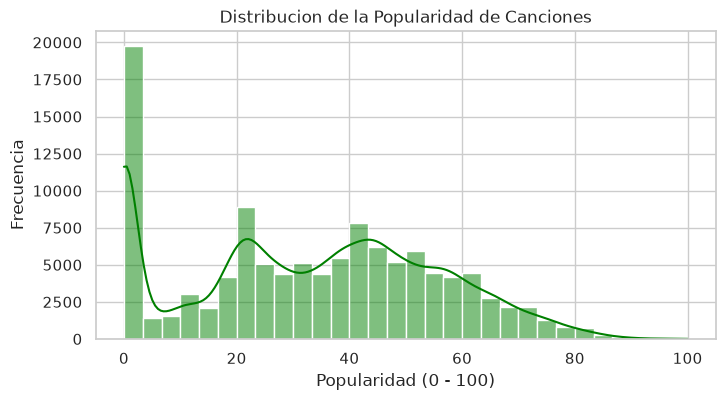

In [46]:

# Distribucion de la Variable objetivo 'popularity'

plt.figure(figsize=(8,4))
sns.histplot(df['popularity'], kde=True, bins=30, color='green')
plt.title('Distribucion de la Popularidad de Canciones')
plt.xlabel('Popularidad (0 - 100)')
plt.ylabel('Frecuencia')
plt.show()

In [47]:

# Creación de Variable Objetivo Binaria para clasificacion

UMBRAL_POPULARIDAD = 50
df['popular_track'] = (df['popularity'] >= UMBRAL_POPULARIDAD).astype(int)

print('\nDistribucion de la variable objetivo binaria (popular_track): ')
df['popular_track'].value_counts(normalize=True)


Distribucion de la variable objetivo binaria (popular_track): 


popular_track
0    0.742395
1    0.257605
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

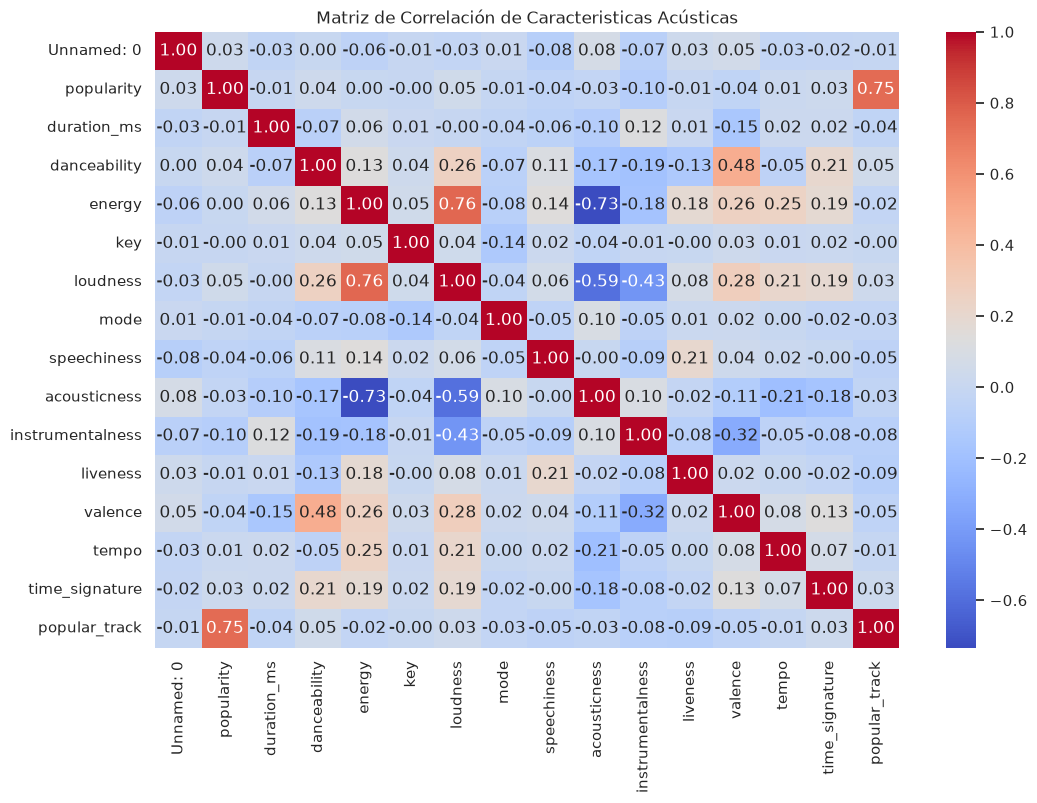

In [48]:

# Matriz de Correlación de variables numéricas

num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación de Caracteristicas Acústicas')
plt.show

## Visualizacion Outliers con grafico Boxplot (Subplots)

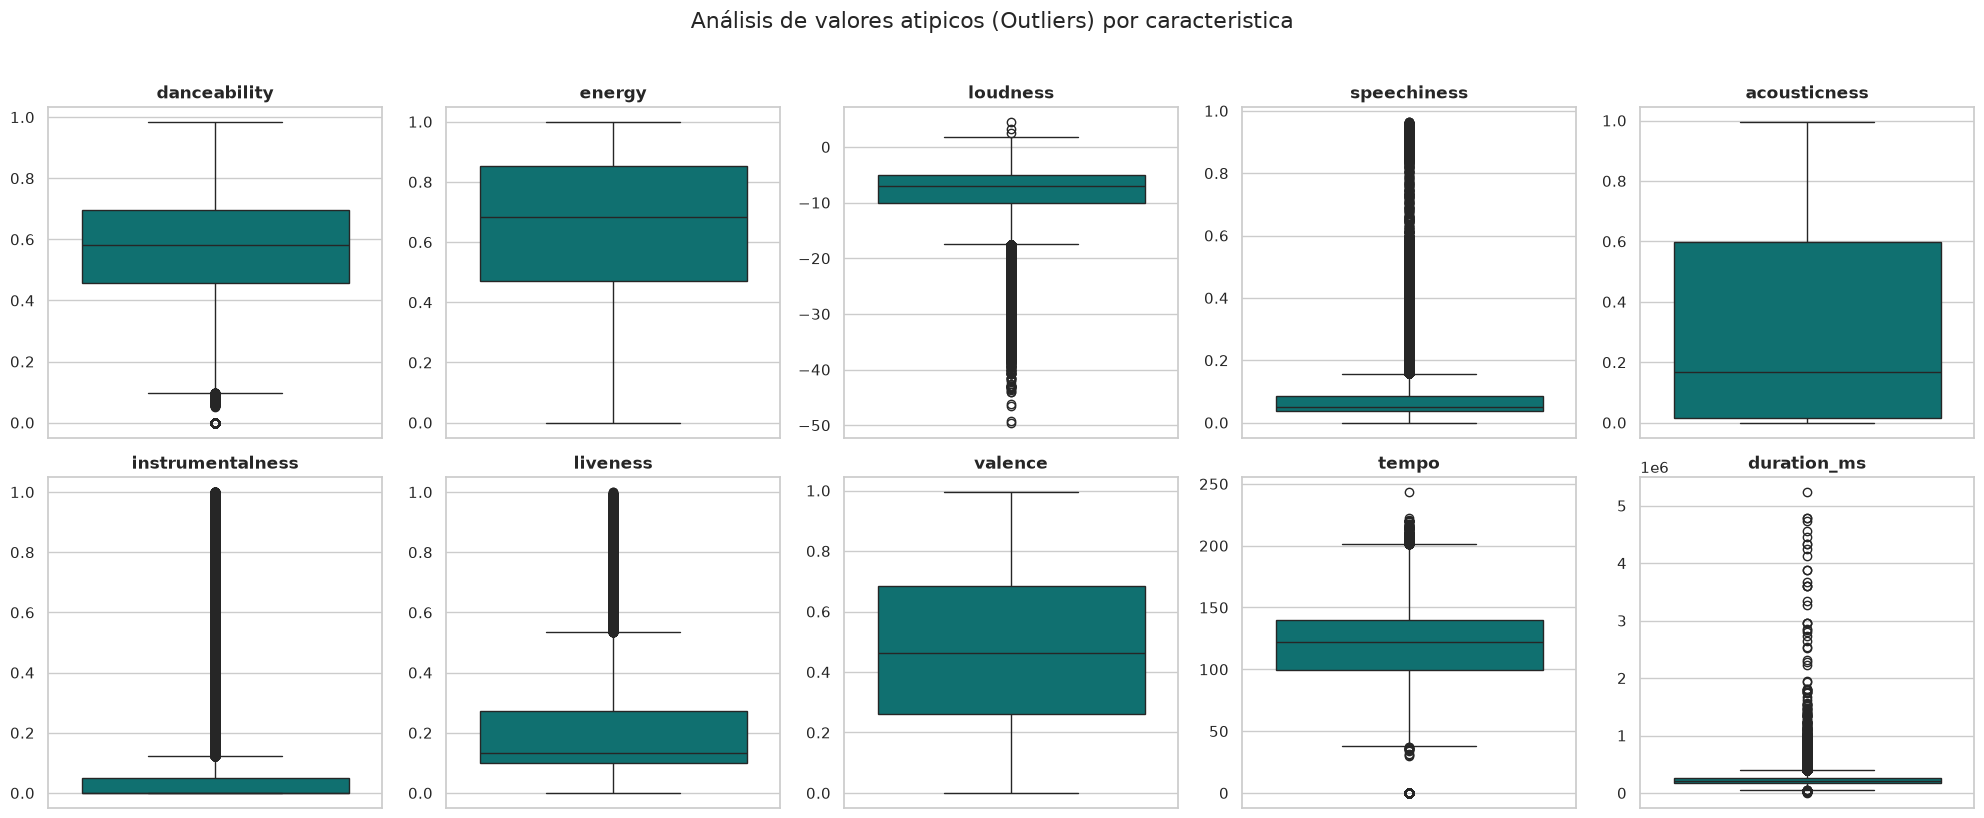

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas numericas del dataset

num_features = [

    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

# Configuracion de la grilla (2x5)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20,8))
axes = axes.flatten()

# Generacion de boxplots individuales

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color='teal')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Análisis de valores atipicos (Outliers) por caracteristica', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



In [50]:

# Funcion para calcular y listar el porcentaje de outliers por variable

def resumen_outliers_iqr(data, columnas):
    resumen = []
    for col in columnas:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        outliers = data[(data[col] < lim_inf) | (data[col] > lim_sup)]
        cant = len(outliers)
        pct = (cant / len(data)) * 100

        resumen.append({
            'Variable':col,
            'Cantidad Outliers': cant,
            'Porcentaje (%)': round(pct,2)
        })
    return pd.DataFrame(resumen)

# Mostrar tabla de resultados
df_iqr = resumen_outliers_iqr(df, num_features)
print(df_iqr.sort_values(by='Porcentaje (%)', ascending=False).to_string(index=False))

        Variable  Cantidad Outliers  Porcentaje (%)
instrumentalness              25246           22.15
     speechiness              13211           11.59
        liveness               8642            7.58
        loudness               6173            5.41
     duration_ms               5617            4.93
    danceability                620            0.54
           tempo                617            0.54
          energy                  0            0.00
    acousticness                  0            0.00
         valence                  0            0.00


# Procesamiento de Datos

A partir de este punto será realizado el procesamiento de datos, en este incluimos todo lo que es:

- Limpieza de datos

- Seleccion de Variables y Outliers

- Division y Escalado (Usando Scikit-learn estandar)

- Creacion y Aplicacion del Pipeline

In [51]:

# Librerias

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [53]:

# Limpieza de datos duplicados y nulos

df = df.drop_duplicates()
df = df.dropna(subset=['popularity'])

df['popular_track'] = (df['popularity'] >= 50).astype(int)

In [55]:

# Seleccion de Variable objetivo y outliers

features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

X = df[features].copy()
y = df['popular_track']

# Limitar outliers directamente con un bucle for (Metodo IQR)

for col in features:

    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    X[col] = X[col].clip(lower= q1 - 1.5 * iqr, upper = q3 + 1.5 * iqr)

In [56]:

# Division y escalado (Scikit-learn)

X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size=0.20, random_state=42, stratify=y
)

print(f'Tamaño de entrenamiento: {X_train.shape[0]} filas')
print(f'Tamaño de prueba: {X_test.shape[0]} filas')

Tamaño de entrenamiento: 91200 filas
Tamaño de prueba: 22800 filas


In [57]:

# Definicion de Pipeline de Preprocesamiento

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Aplicacion del Pipeline

X_train_prepared = num_pipeline.fit_transform(X_train)
X_test_prepared = num_pipeline.transform(X_test)


# Entrenamiento y Modelamiento con Scikit-Learn

En este punto vamos a realizar el entrenamiento de nuestro modelo con Scikit-learn


### Descripcion de modelos a comprar

**Regresion Logistica o LogisticRegression**

El modelo de regresión logística, a pesar de su nombre, es un algoritmo de clasificación, no de regresión. Se utiliza para estimar valores discretos (0 o 1, sí/no, verdadero/falso) a partir de un conjunto de variables independientes. En esencia, este algoritmo calcula la probabilidad de que una instancia pertenezca a una determinada clase, utilizando una función logística que transforma una combinación lineal de las variables independientes.

Fuentes: https://reactivelinux.com/logisticregression-sklearn/

**K-Nearest Neighbors**

El algoritmo de vecinos más cercanos (KNN) es un algoritmo de aprendizaje supervisado no paramétrico utilizado para tareas de clasificación y regresión en aprendizaje automático. Se basa en el concepto de proximidad, asumiendo que los puntos de datos similares se encuentran cerca entre sí. KNN es un algoritmo de aprendizaje perezoso, lo que significa que no requiere una fase de entrenamiento y realiza predicciones almacenando todo el conjunto de datos de entrenamiento y utilizándolo para determinar la clase o el valor de nuevos puntos de datos.

Fuentes: https://www.flowhunt.io/es/glosario/k-nearest-neighbors/

**Arbol de Decision**

Es un modelo predictivo de aprendizaje supervisado que organiza datos en una estructura jerárquica en forma de árbol, que representa una serie de decisiones y sus posibles consecuencias. Se compone de nodos internos que representan una condición sobre características o atributos, ramas que indican el resultado de esas condiciones (los valores de los atributos) y hojas que contienen las predicciones, decisiones finales o resultados.

Fuentes: https://www.codemotion.com/magazine/es/inteligencia-artificial/arboles-de-decision-en-machine-learning-predicciones-efectivas-y-modelos-interpretables/

**Random Forest**

Este algoritmo genera un cierto número de árboles de decisión, siendo entrenado cada uno de ellos con un subconjunto aleatorio de muestras extraídas con reemplazo. Además, durante la división de cada nodo, en lugar de considerar todas las características predictivas para encontrar el mejor criterio de división, solo considera un subconjunto de ellas.

Fuentes: https://interactivechaos.com/es/manual/tutorial-de-machine-learning/random-forest

In [58]:

# Librerias

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)

In [59]:

# Definicion de modelos a comparar

models = {
    'Regresion Logistica': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Arbol de Decision': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

result = []

for name, model in models.items():

    # Entrenamiento
    
    model.fit(X_train_prepared, y_train)

    # Predicciones

    y_pred = model.predict(X_test_prepared)
    y_proba = model.predict_proba(X_test_prepared)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metricas

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    result.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    # Tabla de resultados

    df_result = pd.DataFrame(result).sort_values(by='F1-Score', ascending=False)
    print('\n == TABLA COMPARATIVA ==')
    print(df_result.to_string(index=False))




 == TABLA COMPARATIVA ==
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Regresion Logistica  0.742193   0.380952 0.001362  0.002715 0.607641

 == TABLA COMPARATIVA ==
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
K-Nearest Neighbors  0.740395   0.494978 0.386004  0.433751 0.723988
Regresion Logistica  0.742193   0.380952 0.001362  0.002715 0.607641

 == TABLA COMPARATIVA ==
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
K-Nearest Neighbors  0.740395   0.494978 0.386004  0.433751 0.723988
  Arbol de Decision  0.743202   0.550000 0.016857  0.032711 0.631354
Regresion Logistica  0.742193   0.380952 0.001362  0.002715 0.607641

 == TABLA COMPARATIVA ==
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
K-Nearest Neighbors  0.740395   0.494978 0.386004  0.433751 0.723988
  Arbol de Decision  0.743202   0.550000 0.016857  0.032711 0.631354
      Random Forest  0.744868   0.791667 0.012941  0.025465 0.706593

# Evaluacion Detallada Del Mejor Modelo

Ahora vamos a hacer una evaluacion detallada seleccionando el modelo que saco mejor puntaje en el entrenamiento de los 4 modelos testeados anteriormente


Reporte detallado del mejor modelo: Random Forest
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     16927
           1       0.79      0.01      0.03      5873

    accuracy                           0.74     22800
   macro avg       0.77      0.51      0.44     22800
weighted avg       0.76      0.74      0.64     22800



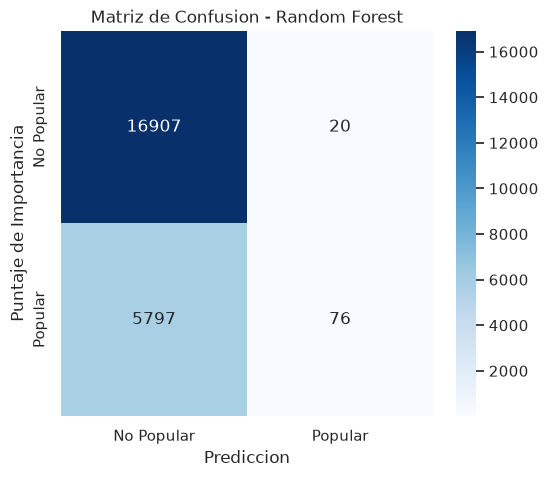

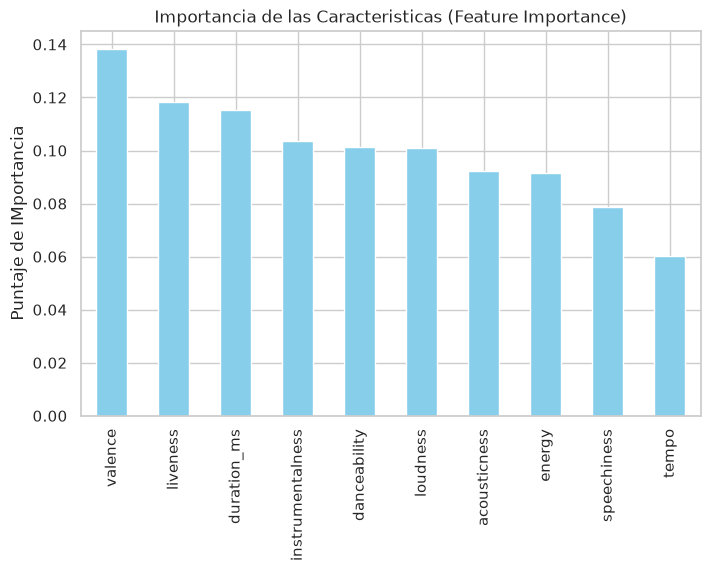

In [60]:

best_model_name = 'Random Forest'
best_model = models[best_model_name]

print(f'\nReporte detallado del mejor modelo: {best_model_name}')
y_best_pred = best_model.predict(X_test_prepared)
print(classification_report(y_test, y_best_pred))

# Matriz de confusion

cm = confusion_matrix(y_test, y_best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Popular', 'Popular'],
            yticklabels=['No Popular', 'Popular'])
plt.title(f'Matriz de Confusion - {best_model_name}')
plt.xlabel('Prediccion')
plt.ylabel('Puntaje de Importancia')
plt.show()

# Importancia de Caracteristicas (Si sale Random Forest o Arboles)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    importances.plot(kind='bar', color='skyblue')
    plt.title('Importancia de las Caracteristicas (Feature Importance)')
    plt.ylabel('Puntaje de IMportancia')
    plt.show()